In [4]:
import os
import cv2
import shutil
import chromadb
import numpy as np
import pandas as pd
from PIL import Image
from dotenv import load_dotenv
from matplotlib import pyplot as plt
from qdrant_client import QdrantClient
from huggingface_hub import get_collection
from inference_sdk import InferenceHTTPClient
from chromadb.utils.data_loaders import ImageLoader
from sentence_transformers import SentenceTransformer, util
from qdrant_client.models import VectorParams, Distance, PointStruct
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction


In [2]:
load_dotenv()

collection_name = os.getenv("COLLECTION_NAME")

chroma_client = chromadb.CloudClient(
    api_key=os.getenv("CHROMA_API_KEY"),
    tenant=os.getenv("CHROMA_TENANT"),
    database=os.getenv("CHROMA_DATABASE"),
)
qdrant_client = QdrantClient(url=os.getenv("QDRANT_ENDPOINT"), port=6333, api_key=os.getenv("QDRANT_API_KEY"))

In [66]:
if not os.path.exists('apparels'):
    os.makedirs('apparels')
dataset = pd.read_csv("styles.csv")
# women = dataset[dataset['gender'] == 'Women']
# women_apparels = women[women['masterCategory'] == 'Apparel']
# women_apparels.to_csv('women-apparels.csv')

# men = dataset[dataset['gender'] == 'Men']
# men_apparels = men[men['masterCategory'] == 'Apparel']
# print(women_apparels)

only_apparels = dataset[dataset['masterCategory'] == 'Apparel']
only_apparels.to_csv('apparels.csv')

only_apparels = only_apparels.dropna()
print(only_apparels.shape)

# Copy File From Images Folder To New Folder
for apparel_id in only_apparels['id']:
    if os.path.isfile(f"images/{apparel_id}.jpg"):
        shutil.copyfile(f"images/{apparel_id}.jpg", f"apparels/{apparel_id}.jpg")

(21369, 10)


In [8]:
model = SentenceTransformer("clip-ViT-B-32")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 8317.47it/s]
CLIPModel LOAD REPORT from: /Users/star/.cache/huggingface/hub/models--sentence-transformers--clip-ViT-B-32/snapshots/327ab6726d33c0e22f920c83f2ff9e4bd38ca37f/0_CLIPModel
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
def get_image(path):
    image = Image.open(path)
    return image

def remove_extension(image):
    return os.path.splitext(image)[0]

# SentenceTransformer Embeddings (Unused)

In [68]:
def embed_images(batch_size=2000):

    file_names = [f.name for f in os.scandir("apparels") if f.name.endswith(".jpg")]
    print(f"Found {len(file_names)} images")
    all_embeddings = []

    for start in range(0, len(file_names), batch_size):
        batch_files = file_names[start:start + batch_size]
        images = []
        for f in batch_files:
            img = Image.open(f"apparels/{f}")
            img.load()
            img_copy = img.copy()
            img.close()
            images.append(img_copy)

        batch_embeddings = model.encode(images)
        all_embeddings.append(batch_embeddings)
        print(f"Batch {start // batch_size + 1}: embedded {len(batch_files)} images ({start + len(batch_files)}/{len(file_names)})")

        for img in images:
            img.close()
        del images

    image_embeddings = np.concatenate(all_embeddings, axis=0)
    print(f"Total shape: {image_embeddings.shape}")

    cos_scores = util.cos_sim(image_embeddings[0], image_embeddings[2])
    print(f"Cosine similarity [0] vs [2]: {cos_scores[0]}")
    return image_embeddings

image_embeddings = embed_images()

Found 21364 images
Batch 1: embedded 2000 images (2000/21364)
Batch 2: embedded 2000 images (4000/21364)
Batch 3: embedded 2000 images (6000/21364)
Batch 4: embedded 2000 images (8000/21364)
Batch 5: embedded 2000 images (10000/21364)
Batch 6: embedded 2000 images (12000/21364)
Batch 7: embedded 2000 images (14000/21364)
Batch 8: embedded 2000 images (16000/21364)
Batch 9: embedded 2000 images (18000/21364)
Batch 10: embedded 2000 images (20000/21364)
Batch 11: embedded 1364 images (21364/21364)
Total shape: (21364, 512)
Cosine similarity [0] vs [2]: tensor([0.7444])


# ChromaDB Search

In [ ]:
collection = chroma_client.get_or_create_collection(
    name=collection_name,
    embedding_function=OpenCLIPEmbeddingFunction(),
    data_loader=ImageLoader()
)

images = os.listdir("apparels")
ids = []
documents = []
metadata = []
uris = []

women_dataset = pd.read_csv("apparels.csv")
for id in images:
    remove_ext = os.path.splitext(id)[0]
    row = women_dataset[women_dataset['id'] == int(remove_ext)]
    ids.append(remove_ext)
    # documents.append(row['productDisplayName'].item())
    metadata.append({ "name":row['productDisplayName'].item(), "sub_category": row["subCategory"].item(), "article_type": row["articleType"].item(), "base_color": row["baseColour"].item(), "season": row["season"].item(), "usage": row["usage"].item() })
    uris.append(f"apparels/{id}")

for i in range(0, len(ids), 100):
    collection.add(
        ids=ids[i:i + 100],
        uris=uris[i:i + 100],
        metadatas=metadata[i:i + 100],
    )
    print(f"Added {i + len(ids[i:i + 100])}/{len(ids)}")
# print(ids)
# print(documents)
# print(metadata)
# print(uris)

Added 100/21364


<function remove_extension at 0x131012200>
      Unnamed: 0     id gender masterCategory subCategory articleType  \
5241       26845  54548  Women        Apparel     Topwear      Tunics   

     baseColour  season    year   usage              productDisplayName  
5241     Yellow  Summer  2012.0  Casual  Global Desi Women Yellow Tunic  


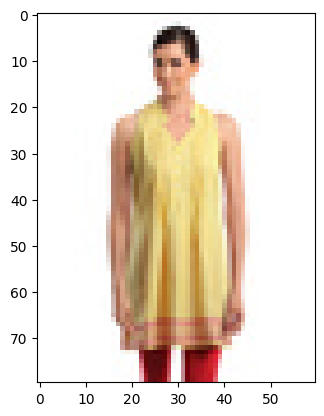

{'ids': [['57042', '3961', '36494', '51802', '41378', '21659', '59090', '59721', '52462', '25826']], 'distances': [[0.7385733, 0.74999315, 0.8211621, 0.8432186, 0.8459749, 0.8534991, 0.85948473, 0.8642593, 0.8644113, 0.87268245]], 'embeddings': None, 'metadatas': [[{'base_color': 'Black', 'article_type': 'Dresses', 'usage': 'Casual', 'sub_category': 'Dress', 'name': 'Elle Black Dress', 'season': 'Summer'}, {'name': 'Jealous 21 Women Black Shimmery Halter Neck Top', 'sub_category': 'Topwear', 'usage': 'Casual', 'base_color': 'Black', 'season': 'Summer', 'article_type': 'Tshirts'}, {'name': 'Folklore Women Printed Black Kurta', 'usage': 'Ethnic', 'article_type': 'Kurtas', 'sub_category': 'Topwear', 'base_color': 'Black', 'season': 'Summer'}, {'base_color': 'Navy Blue', 'season': 'Summer', 'article_type': 'Nightdress', 'usage': 'Casual', 'name': 'Bwitch  Navy Blue  Nightdress', 'sub_category': 'Loungewear and Nightwear'}, {'name': 'Wrangler Women Maria Black Top', 'season': 'Summer', 'art

In [27]:

search_images = os.listdir("women-images")[500:]
image = cv2.imread(f"women-images/{search_images[0]}")
color_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
item = remove_extension(search_images[0])
print(remove_extension)
print(women_dataset[women_dataset['id'] == int(item)])
plt.imshow(color_image)
plt.show()
results = collection.query(
    # query_images=[color_image],
    query_texts=["black dresses"],
    include=['uris', 'distances', 'metadatas']
)
print(results)

# QDRANT Search

In [70]:

print(len(image_embeddings))
print(qdrant_client.get_collections())
if not qdrant_client.collection_exists(collection_name):
    qdrant_client.create_collection(
      collection_name=collection_name,
      vectors_config=VectorParams(size=512, distance=Distance.COSINE),
   )

apparels = os.listdir("apparels")
apparel_dataset = pd.read_csv("apparels.csv")
points = []
for index, id in enumerate(apparels):
    remove_ext = os.path.splitext(id)[0]
    row = apparel_dataset[apparel_dataset['id'] == int(remove_ext)]
    points.append(PointStruct(id=int(remove_ext), vector=image_embeddings[index], payload={ "name":row['productDisplayName'].item(), "sub_category": row["subCategory"].item(), "article_type": row["articleType"].item(), "base_color": row["baseColour"].item(), "season": row["season"].item(), "usage": row["usage"].item() }))


for i in range(0, len(points), 500):
    batch = points[i:i + 500]
    qdrant_client.upsert(
        collection_name=collection_name,
        wait=True,
        points=batch
    )
    print(f"Upserted {i + len(batch)}/{len(points)}")

21364
collections=[CollectionDescription(name='image-search-big')]
Upserted 500/21364
Upserted 1000/21364
Upserted 1500/21364
Upserted 2000/21364
Upserted 2500/21364
Upserted 3000/21364
Upserted 3500/21364
Upserted 4000/21364
Upserted 4500/21364
Upserted 5000/21364
Upserted 5500/21364
Upserted 6000/21364
Upserted 6500/21364
Upserted 7000/21364
Upserted 7500/21364
Upserted 8000/21364
Upserted 8500/21364
Upserted 9000/21364
Upserted 9500/21364
Upserted 10000/21364
Upserted 10500/21364
Upserted 11000/21364
Upserted 11500/21364
Upserted 12000/21364
Upserted 12500/21364
Upserted 13000/21364
Upserted 13500/21364
Upserted 14000/21364
Upserted 14500/21364
Upserted 15000/21364
Upserted 15500/21364
Upserted 16000/21364
Upserted 16500/21364
Upserted 17000/21364
Upserted 17500/21364
Upserted 18000/21364
Upserted 18500/21364
Upserted 19000/21364
Upserted 19500/21364
Upserted 20000/21364
Upserted 20500/21364
Upserted 21000/21364
Upserted 21364/21364


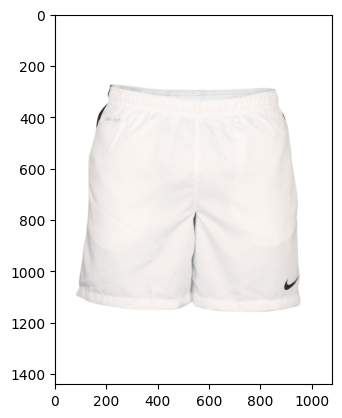

points=[ScoredPoint(id=56795, version=198, score=1.0, payload={'name': 'Horsefly Men Blue Jeans', 'sub_category': 'Bottomwear', 'article_type': 'Jeans', 'base_color': 'Blue', 'season': 'Summer', 'usage': 'Casual'}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=19096, version=198, score=0.98734814, payload={'name': 'Mother Earth Women Calssic Maroon Kurta', 'sub_category': 'Topwear', 'article_type': 'Kurtas', 'base_color': 'Maroon', 'season': 'Fall', 'usage': 'Ethnic'}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=39811, version=197, score=0.98329675, payload={'name': 'Peter England Men Navy Blue Formal Trousers', 'sub_category': 'Bottomwear', 'article_type': 'Trousers', 'base_color': 'Navy Blue', 'season': 'Spring', 'usage': 'Formal'}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=59631, version=88, score=0.9828396, payload={'name': 'FNF Red & Gold Collection for Wedding Sari', 'sub_category': 'Saree', 'article_type': 'Sarees', 'base_

In [56]:
search_apparels = os.listdir("apparels")[500:]
image = cv2.imread(f"apparels/{search_apparels[0]}")
color_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
item = remove_extension(search_apparels[0])
# print(remove_extension)
# print(women_dataset[women_dataset['id'] == int(item)])
plt.imshow(color_image)
plt.show()

embedding = model.encode(get_image(f"apparels/{search_apparels[0]}"))
# print(len(embedding))
# print(list(embedding))
search_result = qdrant_client.query_points(
    collection_name=collection_name,
    query=embedding.tolist(),
    limit=5
)
print(search_result)